<a href="https://colab.research.google.com/github/gurudsguruds2006-ui/Startup-investment-/blob/main/Guru_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("/content/acquisitions (1).csv")

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9562 entries, 0 to 9561
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   9562 non-null   int64  
 1   acquisition_id       9562 non-null   int64  
 2   acquiring_object_id  9562 non-null   object 
 3   acquired_object_id   9561 non-null   object 
 4   term_code            1906 non-null   object 
 5   price_amount         9562 non-null   float64
 6   price_currency_code  9558 non-null   object 
 7   acquired_at          9533 non-null   object 
 8   source_url           8566 non-null   object 
 9   source_description   8590 non-null   object 
 10  created_at           9562 non-null   object 
 11  updated_at           9562 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 896.6+ KB


In [25]:
df.shape

(9562, 12)

In [26]:
df.isnull().sum()

,0
id,0
acquisition_id,0
acquiring_object_id,0
acquired_object_id,1
term_code,7656
price_amount,0
price_currency_code,4
acquired_at,29
source_url,996
source_description,972


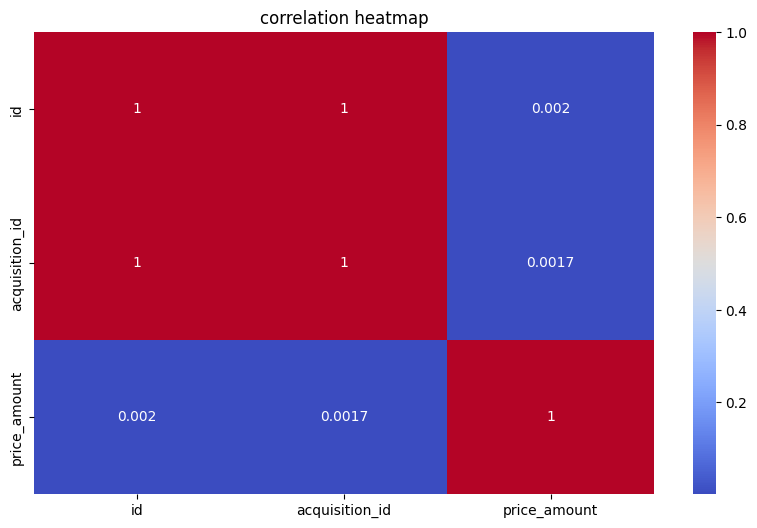

In [27]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

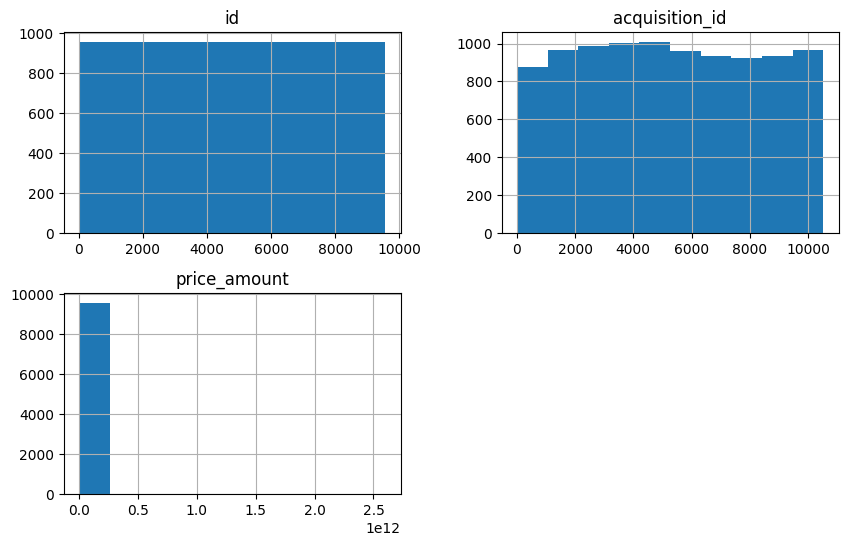

In [28]:
df.hist(figsize=(10,6))
plt.show

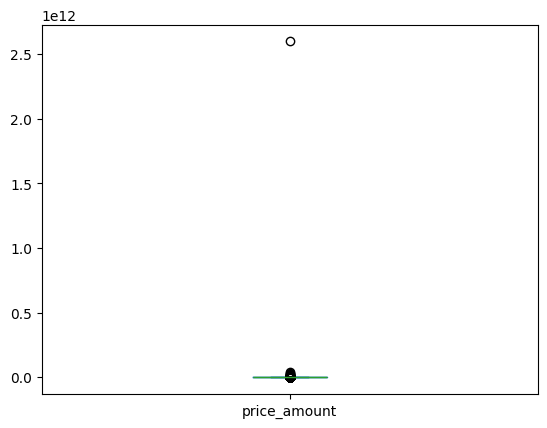

In [29]:
df['price_amount'].plot.box()
plt.show()

In [30]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [31]:
for col in df.select_dtypes(include='object'):
    df[col]=df[col].fillna(df[col].mode()[0])

In [32]:
numeric_df = df.select_dtypes(include=['number'])
Q1 =numeric_df.quantile(0.25)
Q3 =numeric_df.quantile(0.75)
IQR =Q3-Q1
outliers = ((numeric_df<(Q1-1.5*IQR)) |
            (numeric_df>(Q3+1.5*IQR)))
print(outliers.sum())

id                   0
acquisition_id       0
price_amount      2345
dtype: int64


In [33]:
numeric_df = numeric_df[~((numeric_df<(Q1-1.5*IQR))|
          (numeric_df>(Q3+1.5*IQR))).any(axis=1)]

In [34]:
for col in df.select_dtypes(include=np.number):
    df[col]=np.log1p(df[col])

In [35]:
df.head()

,id,acquisition_id,acquiring_object_id,acquired_object_id,term_code,price_amount,price_currency_code,acquired_at,source_url,source_description,created_at,updated_at
0,0.693147,0.693147,c:11,c:10,cash,16.811243,USD,2007-05-30,http://venturebeat.com/2007/05/30/fox-interact...,Fox Interactive confirms purchase of Photobuck...,2007-05-31 22:19:54,2008-05-21 19:23:44
1,1.098612,2.079442,c:59,c:72,cash,17.909855,USD,2007-07-01,http://www.techcrunch.com/2007/07/02/deal-is-c...,Deal is Confirmed: Google Acquired GrandCentral,2007-07-03 08:14:50,2011-05-06 21:51:05
2,1.386294,2.197225,c:24,c:132,cash,19.450300,USD,2007-05-01,http://www.techcrunch.com/2007/05/30/cbs-acqui...,CBS Acquires Europeâs Last.fm for $280 million,2007-07-12 04:19:24,2008-05-19 04:48:50
3,1.609438,2.302585,c:59,c:155,cash,18.420681,USD,2007-06-01,http://techcrunch.com/2007/05/23/100-million-p...,$100 Million Payday For Feedburner  This Deal...,2007-07-13 09:52:59,2012-06-05 03:22:17
4,1.791759,2.397895,c:212,c:215,cash,17.034386,USD,2007-07-01,http://blog.seattlepi.nwsource.com/venture/arc...,seatlepi.com,2007-07-20 05:29:07,2008-02-25 00:23:47


In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
num_cols = df.select_dtypes(include=np.number)
df[num_cols.columns]=scaler.fit_transform(num_cols)

In [37]:
df.head()

,id,acquisition_id,acquiring_object_id,acquired_object_id,term_code,price_amount,price_currency_code,acquired_at,source_url,source_description,created_at,updated_at
0,0.000000,0.000000,c:11,c:10,cash,0.588083,USD,2007-05-30,http://venturebeat.com/2007/05/30/fox-interact...,Fox Interactive confirms purchase of Photobuck...,2007-05-31 22:19:54,2008-05-21 19:23:44
1,0.047857,0.161783,c:59,c:72,cash,0.626514,USD,2007-07-01,http://www.techcrunch.com/2007/07/02/deal-is-c...,Deal is Confirmed: Google Acquired GrandCentral,2007-07-03 08:14:50,2011-05-06 21:51:05
2,0.081811,0.175529,c:24,c:132,cash,0.680401,USD,2007-05-01,http://www.techcrunch.com/2007/05/30/cbs-acqui...,CBS Acquires Europeâs Last.fm for $280 million,2007-07-12 04:19:24,2008-05-19 04:48:50
3,0.108149,0.187825,c:59,c:155,cash,0.644383,USD,2007-06-01,http://techcrunch.com/2007/05/23/100-million-p...,$100 Million Payday For Feedburner  This Deal...,2007-07-13 09:52:59,2012-06-05 03:22:17
4,0.129668,0.198947,c:212,c:215,cash,0.595889,USD,2007-07-01,http://blog.seattlepi.nwsource.com/venture/arc...,seatlepi.com,2007-07-20 05:29:07,2008-02-25 00:23:47


In [38]:
df.to_csv("cleaned_dataset.csv",index=False)